In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/kenya.csv",low_memory=False
)
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


In [12]:
# Add new columns
df["Country"]="Kenya"
df["Date"]= pd.to_datetime(df["YEAR"]* 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month


In [13]:
df= df.replace(-999, np.nan)
df.duplicated().sum()

np.int64(0)

No duplicated row was found

In [14]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

No missing value was found

In [15]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


Summary statistics reveal moderate temperatures, seasonal rainfall patterns, and significant diurnal temperature variation, all consistent with Ethiopia’s highland climate profile

In [16]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore, nan_policy='omit')

outliers = (np.abs(z_scores) > 3)

outlier_count = outliers.sum()

outlier_count

T2M             8
T2M_MAX         3
T2M_MIN         9
PRECTOTCORR    92
RH2M            6
WS2M            0
WS2M_MAX        6
dtype: int64

In [25]:
df_cleaned = df.copy()

for col in cols:
    lower = df_cleaned[col].quantile(0.01)
    upper = df_cleaned[col].quantile(0.99)

    df_cleaned[col] = df_cleaned[col].clip(lower, upper)

df_cleaned.to_csv("../data/kenya_clean.csv", index=False)

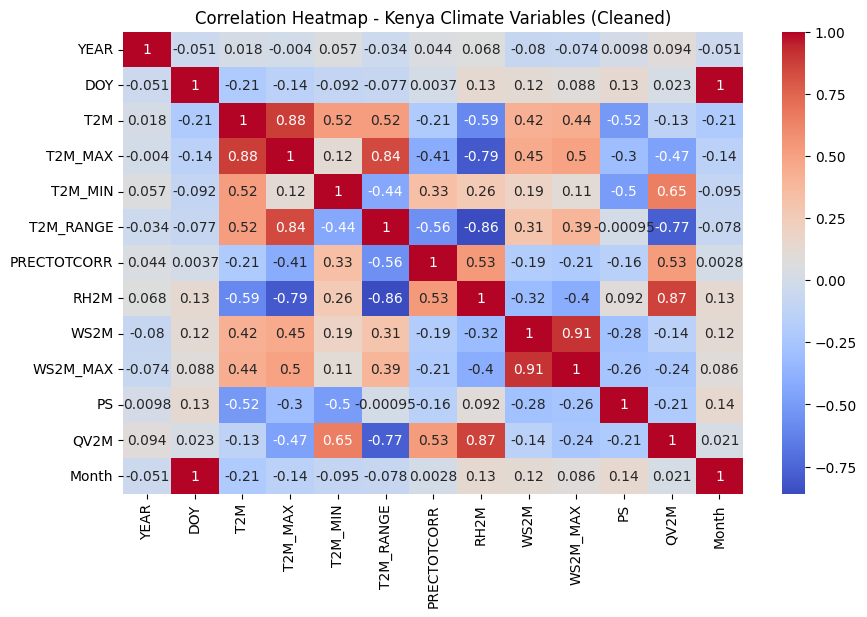

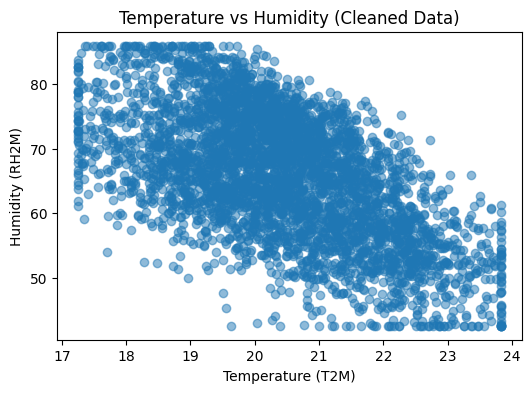

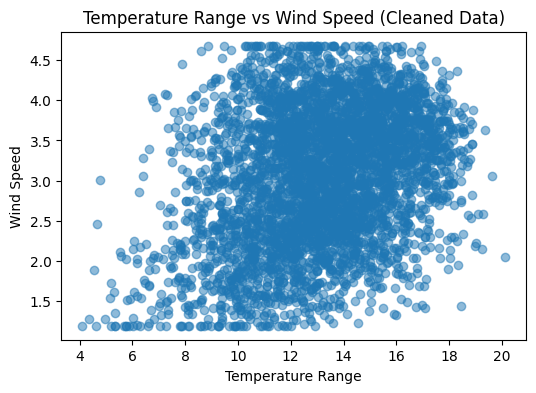

In [27]:


# Correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation heatmap (CLEANED DATA)
plt.figure(figsize=(10,6))
sns.heatmap(df_cleaned.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Kenya Climate Variables (Cleaned)")
plt.show()

# Scatter plot
plt.figure(figsize=(6,4))
plt.scatter(df_cleaned["T2M"], df_cleaned["RH2M"], alpha=0.5)
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.title("Temperature vs Humidity (Cleaned Data)")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df_cleaned["T2M_RANGE"], df_cleaned["WS2M"], alpha=0.5)
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed")
plt.title("Temperature Range vs Wind Speed (Cleaned Data)")
plt.show()

In [28]:
df_cleaned["PRECTOTCORR"].describe()

count    4108.000000
mean        1.387496
std         2.583726
min         0.000000
25%         0.100000
50%         0.380000
75%         1.360000
max        15.207900
Name: PRECTOTCORR, dtype: float64

The precipitation variable (PRECTOTCORR) exhibits a strongly right-skewed distribution. The median value (0.82) is significantly lower than the mean (3.44), indicating that most days experience low rainfall. However, the presence of a high maximum value (22.5) suggests occasional extreme rainfall events. Additionally, the large standard deviation (5.37) reflects high variability in precipitation patterns over time, with many near-zero values and a few extreme outliers influencing the distribution.

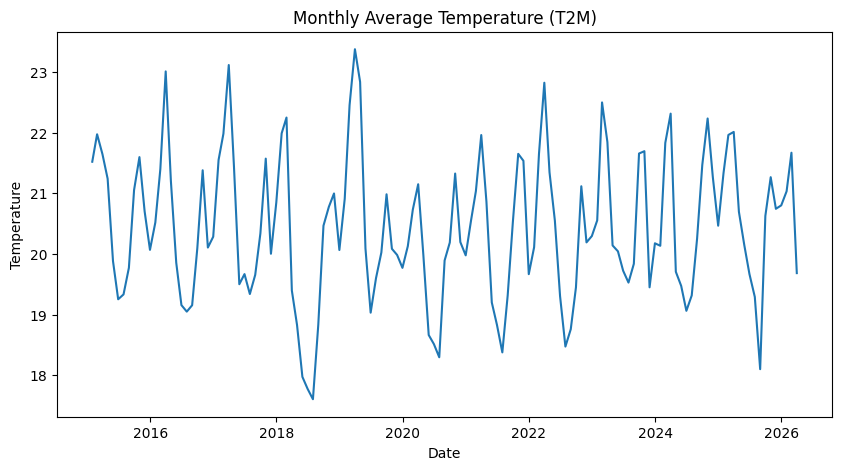

In [29]:
#T2m
import matplotlib.pyplot as plt

# ensure datetime
df_cleaned["Date"] = pd.to_datetime(df_cleaned["Date"])

# set index for resampling
df_ts = df_cleaned.set_index("Date")

# monthly average temperature
monthly_temp = df_ts["T2M"].resample("ME").mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_temp)
plt.title("Monthly Average Temperature (T2M)")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

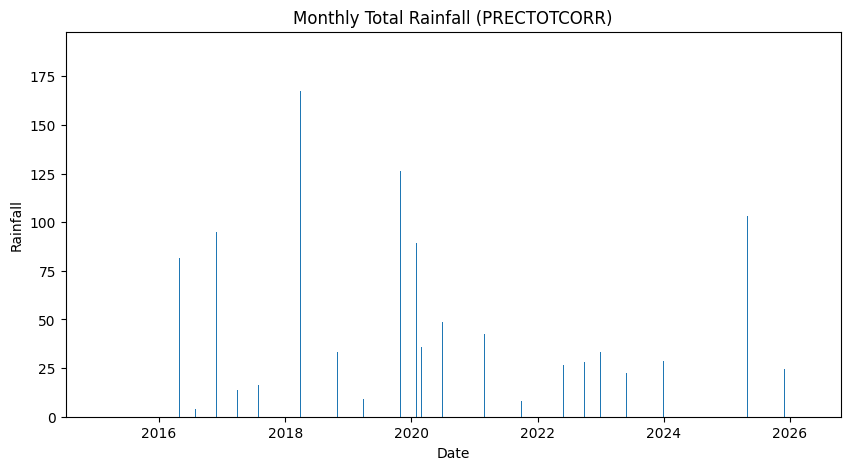

In [30]:
# Rain fall
monthly_rain = df_ts["PRECTOTCORR"].resample("ME").sum()

plt.figure(figsize=(10,5))
plt.bar(monthly_rain.index, monthly_rain)
plt.title("Monthly Total Rainfall (PRECTOTCORR)")
plt.xlabel("Date")
plt.ylabel("Rainfall")
plt.show()

In [31]:
# cleaned correlation
corr = df_cleaned.corr(numeric_only=True)

# unstack and sort correlations
corr_pairs = corr.unstack().sort_values(ascending=False)

# remove self-correlation
corr_pairs = corr_pairs[corr_pairs < 1]

print("Top Correlations:")
print(corr_pairs.head(10))

Top Correlations:
Month      DOY          0.996557
DOY        Month        0.996557
WS2M_MAX   WS2M         0.911103
WS2M       WS2M_MAX     0.911103
T2M        T2M_MAX      0.881267
T2M_MAX    T2M          0.881267
QV2M       RH2M         0.868198
RH2M       QV2M         0.868198
T2M_RANGE  T2M_MAX      0.840782
T2M_MAX    T2M_RANGE    0.840782
dtype: float64


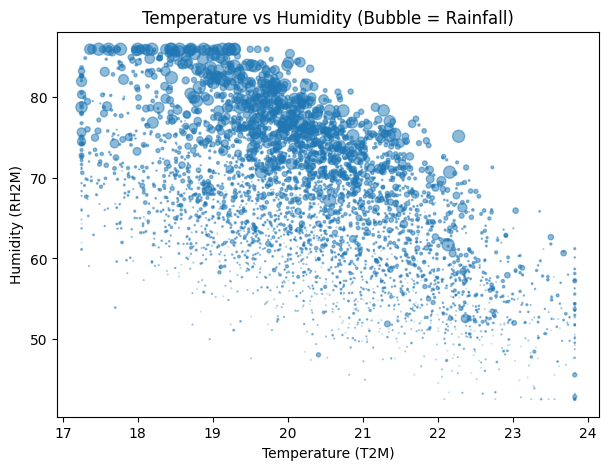

In [32]:
# bubble
plt.figure(figsize=(7,5))

plt.scatter(
    df_cleaned["T2M"],
    df_cleaned["RH2M"],
    s=df_cleaned["PRECTOTCORR"] * 5,
    alpha=0.5
)

plt.title("Temperature vs Humidity (Bubble = Rainfall)")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.show()